# Transformation Matrix Analysis

This notebook is designed to analyze the transformation matrices of all Meta Quest 2 calibration sessions.

In [2]:
import cv2
import os
import numpy as np 
import os
import pandas as pd
import json
from tqdm import tqdm
import matplotlib.pyplot as plt
import importlib

import helpers as h
importlib.reload(h)

pd.options.mode.chained_assignment = None  # default='warn'

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.
Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


## Part 1: Getting all trial directories

In [3]:
def get_deepest_subdirs(root_dir, exclusions=None):
    deepest = set()
    for dirpath, dirnames, filenames in os.walk(root_dir):
        dirnames[:] = [d for d in dirnames if d not in exclusions]
        if not dirnames:
            # Ensure THIS directory itself is not excluded
            if os.path.basename(dirpath) not in exclusions:
                deepest.add(dirpath)
    return list(deepest)

def get_trial_dirs(root_dir:str, verbose:bool=False):
    trial_dirs = get_deepest_subdirs(root_dir, ['frames', 'anchor_frames', 'estimation_frames', 'validations'])
    if verbose: display(trial_dirs)
    return trial_dirs

trial_dirs = get_trial_dirs(os.path.join('.','captures', 'mq2'), verbose=True)

['.\\captures\\mq2\\58-yes-iphone',
 '.\\captures\\mq2\\58-no-iphone',
 '.\\captures\\mq2\\58-yes-mac',
 '.\\captures\\mq2\\68-no-iphone',
 '.\\captures\\mq2\\68-yes-pc_hor',
 '.\\captures\\mq2\\68-yes-mac',
 '.\\captures\\mq2\\68-no-mac',
 '.\\captures\\mq2\\68-no-android',
 '.\\captures\\mq2\\68-yes-iphone',
 '.\\captures\\mq2\\68-yes-pc_ver',
 '.\\captures\\mq2\\58-yes-pc_hor',
 '.\\captures\\mq2\\58-no-pc_hor-2',
 '.\\captures\\mq2\\58-no-pc_ver',
 '.\\captures\\mq2\\58-no-mac',
 '.\\captures\\mq2\\68-no-pc_ver',
 '.\\captures\\mq2\\58-yes-pc_ver',
 '.\\captures\\mq2\\68-no-pc_hor',
 '.\\captures\\mq2\\68-yes-android',
 '.\\captures\\mq2\\58-yes-android',
 '.\\captures\\mq2\\58-no-pc_hor',
 '.\\captures\\mq2\\58-no-android']

## Part 2: Extracting Frames from Videos

All trials in `./captures/mq2/` are expected to have the following files:

- `gaze_targets.csv`: The positions (both world and screen, for each left, center, or right eye) of each gaze target
- `events.csv`: Timestamps of the appearances of each gaze target during calibration
- `video.mp4` or `video.mov`: video files.

When we extract frames, we need to do the following:

1. Join `gaze_targets.csv` and `events.csv` to represent each gaze target's position.
2. Using the timestamps, extract the frame for each calibration target. We also extract the last frame.

> _You might notice this is different from our operations in `calibrate.py`. In fact, this notebook comes from an earlier implementation of the `Unity/` project that separated the timing of the calibration targets and their screen positions into two separate files. Furthermore, we extracted calibration target frames based on timestamps rather than frame counts using OCR; we just made sure to start recording just as the calibration session started. In the latest iteration of the project, calibration target positions and timings are already combined into one `calibrations.csv` file; calibration stages also use OCR with frame counts._


In [4]:
class Frame:
    def __init__(self, target_number, filepath, frame, width, height, left_screen, center_screen, right_screen):
        # Core info
        self.target_number = target_number
        self.filepath = filepath
        self.frame = frame
        self.width = width
        self.height = height

        # Mappings
        self.left = left_screen
        self.center = center_screen
        self.right = right_screen

        # Template Matching
        self.template_bboxes = None
        self.mean_centroid = None
        self.median_centroid = None
        self.transformation_matrix = None

    def getScreenFromVR(self, query_coords):
        assert self.transformation_matrix is not None, "Cannot get screen coordinates without a transformation matrix"
        return np.dot(query_coords, self.transformation_matrix)
    
    def drawBBoxes(self, frame=None, bbox_color=[0,255,255], bbox_thickness=1, draw_centroids:bool=True, centroids_color=[0,255,255]):
        assert self.template_bboxes is not None, "Cannot draw bboxes that don't exist"
        outframe = self.frame.copy() if frame is None else frame.copy()
        for (x1, y1, x2, y2, cx, cy) in self.template_bboxes:
            outframe = cv2.rectangle(outframe, (x1, y1), (x2, y2), bbox_color, bbox_thickness)
            if draw_centroids:
                outframe = cv2.drawMarker(outframe, (int(cx), int(cy)), centroids_color, cv2.MARKER_CROSS, 20, 2)
        return outframe, self.template_bboxes

    def drawMeanCentroid(self, frame=None, centroid_color=[255,255,0]):
        assert self.template_bboxes is not None, "Cannot draw mean centroid from bboxes that don't exist"
        outframe = self.frame.copy() if frame is None else frame.copy()
        center = np.mean([[cx,cy] for (x1, y1, x2, y2, cx, cy) in self.template_bboxes], axis=0)
        outframe = cv2.drawMarker(outframe, (int(center[0]), int(center[1])), centroid_color, cv2.MARKER_CROSS,20,2)
        self.mean_centroid = center
        return outframe
    
    def drawMedianCentroid(self, frame=None, centroid_color=[0,0,0]):
        assert self.template_bboxes is not None, "Cannot draw mean centroid from bboxes that don't exist"
        outframe = self.frame.copy() if frame is None else frame.copy()
        center = np.median([[cx,cy] for (x1, y1, x2, y2, cx, cy) in self.template_bboxes], axis=0)
        outframe = cv2.drawMarker(outframe, (int(center[0]), int(center[1])), centroid_color, cv2.MARKER_TILTED_CROSS,20,2)
        self.median_centroid = center
        return outframe

In [5]:
# Initialize
trials = []
timestamp_offset = 2.0

# Iterate through each trial. Use TQDM for visual feedback
pbar = tqdm(trial_dirs)
for root_dir in pbar:

    # Update progress bar description
    pbar.set_description(f"Extracting frames from \"{root_dir}\"")
    
    # Define filepaths
    events_filepath = os.path.join(root_dir, 'events.csv')
    targets_filepath = os.path.join(root_dir, 'gaze_targets.csv')
    frames_dir = os.path.join(root_dir, 'frames')

    # Extract csv files. Exit early if these don't exist
    events_df = pd.read_csv(events_filepath)
    targets_df = pd.read_csv(targets_filepath)

    # Filter out `Start` and `End` rows in `events_df`
    edf = events_df[~events_df['event'].isin(['Start','End'])]
    edf["target_number"] = edf["target_number"].astype(int)

    # Modify `targets_df` to rmeove `unix_ms` and typecast `target_number` as integer
    tdf = targets_df.drop(columns=['unix_ms'])
    tdf["target_number"] = tdf["target_number"].astype(int)
    
    # Inner Join on `edf` with `targets_df`
    df = pd.merge(left=edf, right=tdf, left_on='target_number', right_on='target_number')

    # Pre-emptively create `frames` directory
    os.makedirs(frames_dir, exist_ok=True)

    # Find `video` file in the root directory
    videos = h.find_files_with_extensions(root_dir, ['.mov','.mp4'])
    if len(videos) == 0:
        print(f"There are no video files in subdirectory \"{root_dir}\"")
        continue
    video_filename = videos[0]
    
    # Initialize 
    cap = cv2.VideoCapture(video_filename)

    if not cap.isOpened():
        print(f"Could not open video \"{video_filename}\"")
        continue
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    frames = []

    # Iterate through all frames
    for index, row in df.iterrows():
        target_time = row['timestamp'] + timestamp_offset
        frame_idx = int(target_time * fps)
        
        # Get screen position for each eye
        left_screen = (row['screen_left_pos_x'], row['screen_left_pos_y'])
        center_screen = (row['screen_center_pos_x'], row['screen_center_pos_y'])
        right_screen = (row['screen_right_pos_x'], row['screen_right_pos_y'])

        # Seek to the desired frame
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)

        # Read frame, move to next row if unable to read frame
        ok, frame = cap.read()
        if not ok:  
            print(f"Warning: Unable to read frame at {target_time}s (frame {frame_idx}).")
            continue
        frames.append(Frame(
            row['target_number'], 
            os.path.join(frames_dir, f"{row['target_number']}.jpg"), 
            frame,
            width,
            height,
            left_screen,
            center_screen,
            right_screen
        ))

    # Release capture
    cap.release()

    # Print each frame, if they exist
    if len(frames) == 0:
        print("No frames detected!")
        continue
    h.mkdirs(frames_dir)
    for f in frames:
        cv2.imwrite(f.filepath, f.frame)

    # Add to trial
    trials.append({
        'root_dir': root_dir,
        'frames': frames
    })


Extracting frames from ".\captures\mq2\58-no-android": 100%|██████████| 21/21 [00:29<00:00,  1.38s/it] 


## Part 3: Template Matching

In [6]:
def estimate_template_from_image(
        src_img, 
        template_img, 
        min_size=10, 
        max_size=50, 
        delta_size=5, 
        thresh=0.9, 
        verbose=True):
    
    # Initialize bounding boxes
    bboxes = []

    # Iterate through possible sizes of the template, upwards to half of the size
    for p in np.arange(min_size, max_size, delta_size):
        
        # Resize the frame
        template_resize = cv2.resize(template_img, (p,p))
       
        # Get particular attributes of the image itself. 
        # We assume transparency, so we have to separate alpha from bgr
        template = template_resize[:,:,0:3]
        alpha = template_resize[:,:,3]
        alpha = cv2.merge([alpha,alpha,alpha])
        
        # get the width and height of the template
        h,w = template.shape[:2]
        
        # Prepare possible locations where the template matches
        loc = []
        
        # Find those matches.
        res = cv2.matchTemplate(src_img, template, cv2.TM_CCORR_NORMED, mask=alpha)

        # threshold
        loc = np.where(res >= thresh)
        if len(loc) > 0:
            for pt in zip(*loc[::-1]):
                bboxes.append((pt[0],pt[1],pt[0]+w,pt[1]+h, pt[0]+(w/2), pt[1]+(h/2)))
    
    # Print and return
    if verbose: print(f"# Detected Bounding Boxes: {len(bboxes)}")
    return bboxes

In [7]:
# Use OpenCV to read anchor image
anchor_filepath = './anchor.png'
anchor_img = cv2.imread(anchor_filepath, cv2.IMREAD_UNCHANGED)

# Initialize
estimations = []

# Iterate through each trial. Use TQDM for visual feedback
pbar = tqdm(trials)
for trial in pbar:

    # Update progress bar description
    pbar.set_description(f"Estimating anchors from frames in \"{trial['root_dir']}\"")

    # Generate output directory for drawn images
    outdir = h.mkdirs(os.path.join(trial['root_dir'], 'anchor_frames'))

    # Iterate through frames
    #for f in frames:
    #    cv2.imwrite(f.filepath, f.frame)

    # For each frame, attempt to estimate the anchor
    for frame in trial['frames']:

        # Estimate
        frame.template_bboxes = estimate_template_from_image(frame.frame, anchor_img, verbose=False)
        
        # Draw
        mean_centroid_frame = frame.drawMeanCentroid()
        median_centroid_frame = frame.drawMedianCentroid(frame=mean_centroid_frame)

        # Render
        cv2.imwrite(os.path.join(outdir, f"{frame.target_number}.jpg"), median_centroid_frame)

Estimating anchors from frames in ".\captures\mq2\58-no-android": 100%|██████████| 21/21 [15:02<00:00, 42.98s/it] 


## Part 4: Identifying Screen Mappings

The centroids detected with template matching above are relative to the top-left corner. Unity's `WorldToScreenPoint` is relative to the bottom-left. However, that doesn't matter, because our transformation matrix can handle this in theory.

For all intents and purposes, let's use the median center.

That being said, we now have a mapping: the median center (corrected to be bottom-left) and the screen position of the target (let's exclude `all`). We can leverage `numpy.linalg.lstsq` (least squares approximation) for that.

We would have to generate a new transformation matrix for each method of recording, but that's not too much of a hassle.

In [8]:
# Iterate through each trial. Use TQDM for visual feedback
pbar = tqdm(trials)

for trial in pbar:

    # Initialize coords arrays
    vr_coords = []
    img_coords = []

    # Iterate each frame
    for frame in trial['frames']:
        # Append the coords for VR coords
        vr_coords.append(frame.center)
        # Append coords for the median centroid
        img_coords.append(frame.median_centroid)

    # Append a new `1` value, then derive the transformation matrix.
    A = np.vstack([np.array(vr_coords).T, np.ones(len(trial['frames']))]).T
    transformation_matrix, res, rank, s = np.linalg.lstsq(A, img_coords, rcond=None)

    # Save the transformation matrix 
    output = {
        'vr_anchors_positions':h.to_serializable(vr_coords),
        'img_anchors_positions':h.to_serializable(img_coords),
        'transformation_matrix':h.to_serializable(transformation_matrix)
    }
    with open(os.path.join(trial['root_dir'], 'transformations.json'), "w") as outfile: 
        json.dump(output, outfile, indent=2)

    print('\t', np.linalg.norm(transformation_matrix))

    # Apply transformation matrix to each frame
    for frame in trial['frames']:
        frame.transformation_matrix = transformation_matrix

100%|██████████| 21/21 [00:00<00:00, 862.70it/s]

	 1200.845190047612
	 1200.8453319393755
	 2998.7569753410553
	 1100.5680800605917
	 1615.9638499699176
	 2756.8842082368315
	 2764.4548845107065
	 2263.631082082076
	 1100.568246684957
	 1557.937272255282
	 1738.259525817436
	 1732.8125384220587
	 1637.8080908321617
	 2993.0030555809835
	 1556.6009343941816
	 1650.8387881444942
	 1596.295777298948
	 2264.1561523238875
	 2471.0944685507625
	 1736.4667479294296
	 2470.7480072058243


To apply the transformation matrix, let's attempt to calculate the screen positions FROM vr coordinates

In [9]:
# Iterate through each trial. Use TQDM for visual feedback
pbar = tqdm(trials)
for trial in pbar:

    # Generate output directory for drawn images
    outdir = h.mkdirs(os.path.join(trial['root_dir'], 'estimation_frames'))
    
    # Iterate each frame
    for frame in trial['frames']:
        
        # Get the vr frames for the center screen
        center_coords = [frame.center[0], frame.center[1], 1]
        # Apply the transformation
        corrected_center_coords = frame.getScreenFromVR(center_coords)
        #corrected_center_coords[1] = frame.height - corrected_center_coords[1]

        # Draw
        outframe = frame.frame.copy()
        outframe = cv2.drawMarker(outframe, (int(frame.median_centroid[0]), int(frame.median_centroid[1])), [225,255,0], cv2.MARKER_DIAMOND,20,2)
        outframe = cv2.drawMarker(outframe, (int(center_coords[0]), int(center_coords[1])), [255,255,0], cv2.MARKER_CROSS,20,2)
        outframe = cv2.drawMarker(outframe, (int(corrected_center_coords[0]), int(corrected_center_coords[1])), [0,0,0], cv2.MARKER_TILTED_CROSS,20,2)

        # Render
        cv2.imwrite(os.path.join(outdir, f"{frame.target_number}.jpg"), outframe)




100%|██████████| 21/21 [00:01<00:00, 10.80it/s]


## Part 5: Differences Between Transformation Matrices

Are there any differences between the transformation matrices in of themselves? In theory, there should be... but we won't know. Let's find out.

In [10]:
transformation_matrices = []
for trial_dir in trial_dirs:
    tname = os.path.basename(os.path.normpath(trial_dir))
    if tname == '58-no-pc_hor-2': continue
    inpath = os.path.join(trial_dir, 'transformations.json')
    if os.path.exists(inpath):
        with open(inpath, 'r') as f:
            tdata = json.load(f)
            if 'transformation_matrix' in tdata:
                transformation_matrices.append({
                    'name':tname, 
                    'transformation_matrix':np.array(tdata['transformation_matrix'])
                })

In [11]:
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
from collections import defaultdict

def parse_name(name):
    """
    Input example:  '060-high-iphone'
    Output:         { 'ipd': '060', 'resolution': 'high', 'device': 'iphone' }
    """
    parts = name.lower().split('-')
    ipd = parts[0] if len(parts) > 0 else "unknown"
    resolution = parts[1] if len(parts) > 1 else "unknown"
    device = parts[2] if len(parts) > 2 else "unknown"
    return {
        "ipd": ipd,
        "resolution": resolution,
        "device": device
    }

def build_distance_matrix(objects, square:bool=False):
    names = [obj["name"] for obj in objects]
    n = len(objects)
    dist = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            A = objects[i]["transformation_matrix"]
            B = objects[j]["transformation_matrix"]
            # Square = Squared Frobenius Distance. More stable. 
            # Otherwise, we look at just Frobenius Distancce
            dist[i, j] = np.sum((A - B)**2) if square else np.linalg.norm(A - B)
    return dist, names

def reorder(dist_matrix, names, order):
    sorted_matrix = dist_matrix[order][:, order]
    sorted_names = [names[i] for i in order]
    return sorted_matrix, sorted_names

def hierarchical_sort(dist_matrix):
    # SciPy expects a condensed form → convert NxN to 1D
    condensed = squareform(dist_matrix, checks=False)
    # perform hierarchical clustering
    Z = linkage(condensed, method="average")
    # extract leaf order → this is the new sorted order
    order = leaves_list(Z)
    return order


def hierarchical_order(dist_matrix):
    condensed = squareform(dist_matrix, checks=False)
    Z = linkage(condensed, method="average")
    return leaves_list(Z)

def grouped_hierarchical_sort(dist_matrix, names, group_by):
    parsed = [parse_name(n) for n in names]
    # Build mapping from group → list of indices
    groups = defaultdict(list)
    for idx, p in enumerate(parsed):
        key = tuple(p[field] for field in group_by)
        groups[key].append(idx)
    # Sort group keys alphabetically for deterministic ordering
    ordered_group_keys = sorted(groups.keys())
    final_order = []
    for key in ordered_group_keys:
        idxs = groups[key]
        # Submatrix for this group
        sub = dist_matrix[np.ix_(idxs, idxs)]
        if len(idxs) > 1:
            # Hierarchical clustering within group
            sub_order = hierarchical_order(sub)
            sorted_sub = [idxs[i] for i in sub_order]
        else:
            sorted_sub = idxs
        final_order.extend(sorted_sub)
    return final_order

def plot_heatmap(dist_matrix, names, title, save_filename:str=None):
    plt.figure(figsize=(6, 5))
    plt.imshow(dist_matrix)
    plt.colorbar(label="Frobenius Difference")

    plt.xticks(range(len(names)), names, rotation=45, ha="right")
    plt.yticks(range(len(names)), names)
    plt.title(title)
    plt.tight_layout()
    if save_filename is not None:
        plt.savefig(save_filename+".png", dpi=300, bbox_inches="tight")
        plt.savefig(save_filename+".svg", dpi=300, bbox_inches="tight")
        plt.savefig(save_filename+".pdf", dpi=300, bbox_inches="tight")
    plt.show()

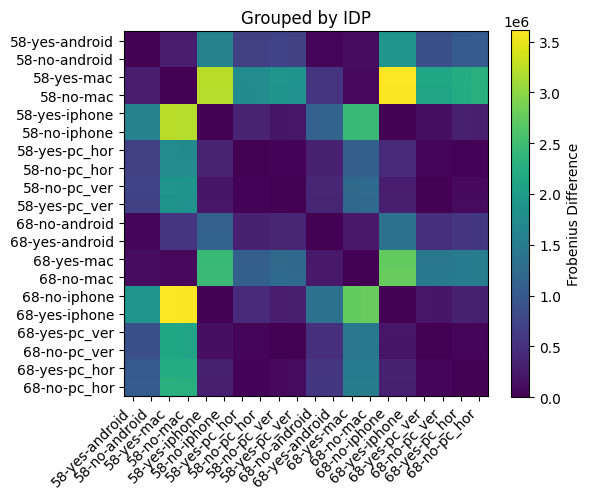

In [12]:
dist_matrix, names = build_distance_matrix(transformation_matrices, square=True)
order = grouped_hierarchical_sort(dist_matrix, names, ['ipd'])
sorted_matrix, sorted_names = reorder(dist_matrix, names, order)
plot_heatmap(sorted_matrix, sorted_names, "Grouped by IDP", save_filename='./analysis/ipd')

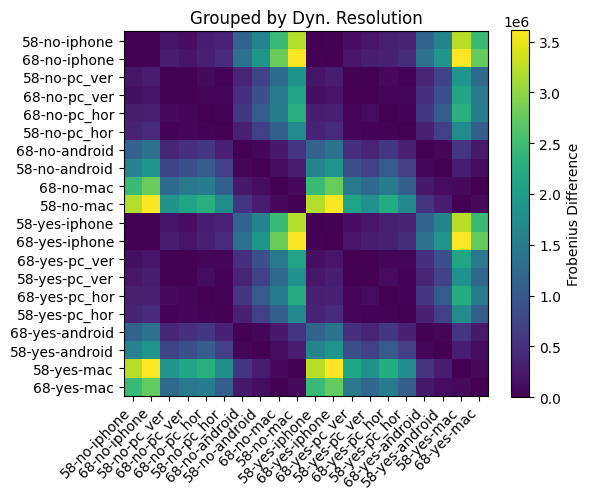

In [13]:
dist_matrix, names = build_distance_matrix(transformation_matrices, square=True)
order = grouped_hierarchical_sort(dist_matrix, names, ['resolution'])
sorted_matrix, sorted_names = reorder(dist_matrix, names, order)
plot_heatmap(sorted_matrix, sorted_names, "Grouped by Dyn. Resolution", save_filename='./analysis/resolution')

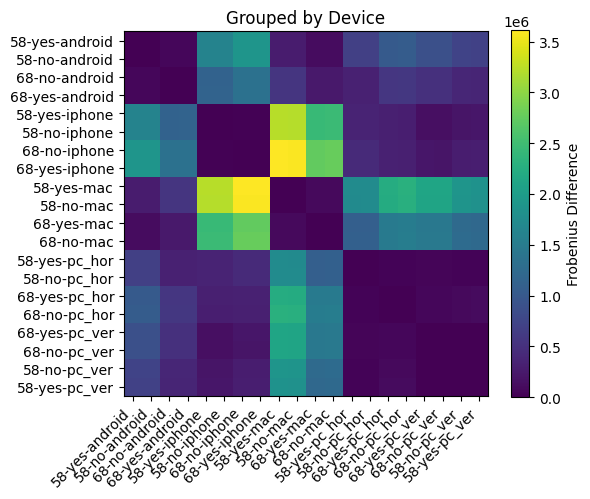

In [14]:
dist_matrix, names = build_distance_matrix(transformation_matrices, square=True)
order = grouped_hierarchical_sort(dist_matrix, names, ['device'])
sorted_matrix, sorted_names = reorder(dist_matrix, names, order)
plot_heatmap(sorted_matrix, sorted_names, "Grouped by Device", save_filename='./analysis/device')

From this, we can derive the following properties about recording:

- Changing between dynamic resolution does NOT affect recording, so no need for a new transformation matrix
- Changing the IPD produces a minor change in transformation matrix, so a re-calculation is needed. However, in a punch, it may be okay to use the same transforamtion matrix.
- Switching recording devices DOES require a different transformation matrix

# Permanova Statistical Analysis

In [16]:
def compute_statistic(distance_matrix, labels):
    """
    Compute T = mean(between-group distances) - mean(within-group distances)
    """
    n = len(labels)
    within = []
    between = []

    for i in range(n):
        for j in range(i + 1, n):
            if labels[i] == labels[j]:
                within.append(distance_matrix[i, j])
            else:
                between.append(distance_matrix[i, j])

    within_mean = np.mean(within) if within else 0
    between_mean = np.mean(between) if between else 0

    return between_mean - within_mean

def permutation_test(distance_matrix, labels, n_permutations=10000, random_state=None):
    """
    Perform permutation test on a distance matrix given group labels.
    """
    rng = np.random.default_rng(random_state)

    # observed statistic
    observed_T = compute_statistic(distance_matrix, labels)

    # null distribution
    permuted_T = np.zeros(n_permutations)

    for i in range(n_permutations):
        shuffled = rng.permutation(labels)
        permuted_T[i] = compute_statistic(distance_matrix, shuffled)

    # p-value (two-sided)
    p_value = np.mean(np.abs(permuted_T) >= np.abs(observed_T))

    return {
        "observed_T": observed_T,
        "p_value": p_value,
        "null_distribution": permuted_T
    }

def parse_labels(label_list):
    df = pd.DataFrame([l.split('-') for l in label_list],
                      columns=['ipd', 'dynamic_res', 'device'])
    return df

In [17]:
meta = parse_labels(sorted_names)

results = {}

for factor in ['ipd', 'dynamic_res', 'device']:
    res = permutation_test(sorted_matrix, meta[factor].values, n_permutations=10000)
    results[factor] = res
    print(f"{factor}: T={res['observed_T']:.4f}, p={res['p_value']:.5f}")

ipd: T=-48371.9690, p=0.69330
dynamic_res: T=-89759.5784, p=0.16580
device: T=974227.2139, p=0.00000
